In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("E_Commerce_Dataset.txt")

In [3]:
df

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [19]:
import numpy as np
#Initialize reproducible random generatie

rng = np.random.default_rng(42)

#Generate 50 random vALUES FOR EACH colum
Study_Hours = rng.integers(1, 10, size = 50)
Attendance = rng.integers(50, 101, size = 50)

#Define pass column using simple rule
Pass = ((Study_Hours * 10 + Attendance) >120).astype(int)

In [20]:
#Create DataFrame

df1 = pd.DataFrame({
    'Study_Hours': Study_Hours,
    'Attendance': Attendance,
    'Pass': Pass})
df1

,Study_Hours,Attendance,Pass
0,1,88,0
1,7,59,1
2,6,68,1
3,4,73,0
4,4,75,0
5,8,52,1
6,1,77,0
7,7,57,1
8,2,87,0
9,1,84,0


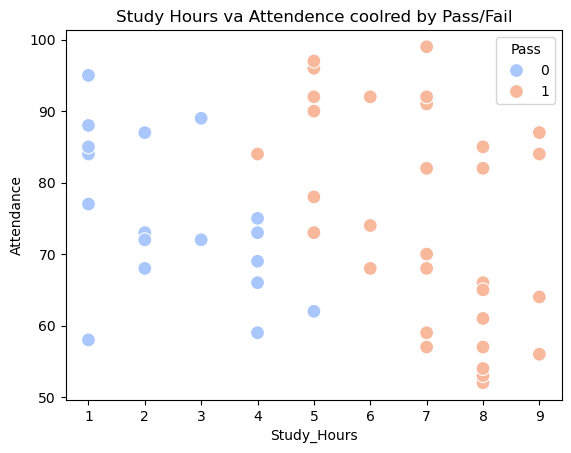

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x =  "Study_Hours", y = 'Attendance', hue = "Pass", data  = df1, palette = 'coolwarm', s = 100)
plt.title("Study Hours va Attendence coolred by Pass/Fail")
plt.show()

## Prepare Data For model

. Features (X): Study_Hourse, Attendence
. Target (y): Pass (0 or 1)

In [36]:
from sklearn.model_selection import train_test_split

X = df1[["Study_Hours", 'Attendance']]
y = df1["Pass"]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size= 0.2, random_state=12)

Train Logistic Regression 

Logistic Regression uses the sigmoid function to predict probabilities (0 to 1)

Sigmoid Function

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

## Make Prediction

In [38]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

In [40]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Pobability_of_Pass': y_prob})

,Actual,Predicted,Pobability_of_Pass
28,1,1,0.710107
46,0,0,0.268531
7,1,1,0.900773
41,1,1,0.998052
36,1,1,0.977034
29,1,0,0.427300
21,0,0,0.037023
48,1,1,0.994356
19,1,1,0.575122
8,0,0,0.023247


In [42]:
# New student data 

new_student = np.array([[9, 25]])    #must be 2d: [[Study_Hours, Attendance]]
                       

In [43]:
# predict pass/fail

pred_class = log_reg.predict(new_student)
print(f"Predicted Class (0=Fail, 1=Pass): {pred_class[0]}")

Predicted Class (0=Fail, 1=Pass): 1


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [44]:
#Predict probability of passing
pred_prob = log_reg.predict_proba(new_student)[0][1]
print(f"Probability of Passing: {pred_prob:.2f}")

Probability of Passing: 0.90


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Evaluate Model

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9

Confusion Matrix:
 [[3 0]
 [1 6]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.86      0.92         7

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10



In [49]:
#Step1 select data point

study = 7
attendance = 80
print(f"Data point -  Study_Hours = {study}, Attendance = {attendance}")

Data point -  Study_Hours = 7, Attendance = 80


In [52]:
#Step2: Get model parameter

b0 = log_reg.intercept_[0]
b1, b2 = log_reg.coef_[0]

print(f"Intercept (b0): {b0:.4f}")
print(f"Coefficient for Study_Hours (b1): {b1:.4f}")
print(f"Coefficient for Attendance (b2): {b2:.4f}")

Intercept (b0): -17.8595
Coefficient for Study_Hours (b1): 1.9005
Coefficient for Attendance (b2): 0.1186


In [54]:
#Sep3: Compute linear combination 

z = b0 + (b1 * study) + (b2 * attendance)
print(f"Linear Combination (z): {z:.4f}")

Linear Combination (z): 4.9342


In [57]:
#Step 4: Apply the Logistic function

y_prob = 1 / (1 + np.exp(-z))
print(f"Predicted Probability of Pass: {y_prob:.4f}")

Predicted Probability of Pass: 0.9929
